# Static-dynamic dRSA permutation test

Tests the static-dynamic dRSA matrix (dynamic time × static time correlation of neural RDMs) against a stimulus-relabelling null, for two versions of the static response shown side by side:

- **raw**: the last-frame image response;
- **2250ms regressed**: the same response after regressing out the response to the 2250 ms movie frame shown as an image (`cfg.previous_static_response`), so only last-frame-specific structure is left.

**Permutation:** each static RDM is expanded to its square form, rows and columns are reordered with one stimulus permutation, and the matrix is condensed again. The **same permutation is applied to every static timepoint**, so the temporal structure of both RDM timeseries is kept and only the stimulus correspondence between static and dynamic is broken. The dynamic RDMs are left untouched. In practice the permutation is applied as one precomputed index into the condensed RDM (`condensed_permutation_index`), which gives exactly the squareform route, and Spearman ranks are computed once because relabelling only reorders the entries.

**Significance** (one-sided, observed > null):
1. **pointwise**: every cell against its own null (uncorrected);
2. **max-statistic**: every cell against the null distribution of the matrix maximum (family-wise corrected over the whole matrix);
3. **cluster-mass**: cells above the pointwise `(1 - cluster_alpha)` null percentile form clusters; each cluster's summed similarity is compared with the largest cluster mass of every null matrix.

In [15]:
import os
import sys
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml


# Locate the repository whether the notebook starts in the project root or scripts/.
working_directory = Path.cwd().resolve()
project_candidates = (working_directory, *working_directory.parents)
PROJECT_ROOT = next(
    candidate for candidate in project_candidates
    if (candidate / "config.yaml").is_file()
)
ENV = os.getenv("MY_ENV", "tiziano_mac_mini")

with open(PROJECT_ROOT / "config.yaml", "r") as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]["paths"]
for source_path in (paths["src_path"], paths["useful_stuff_path"]):
    if source_path not in sys.path:
        sys.path.append(source_path)
    # end if source_path
# end for source_path
from useful_stuff.general_utils import TimeSeries
from project_specific_utils import (
    channelwise_regress_out,
    cluster_permutation_test,
    compute_rdm_timeseries,
    load_natraster,
    match_timed_static_movie_rasters,
    permutation_p_values,
    permuted_cross_temporal_similarity,
    regress_out_rdm_timeseries,
)

## Configuration

`good_channels` uses one-based MATLAB channel numbers with both endpoints included; with `use_reliable_channels` it is intersected with the reliability list of the static session (or of `reliable_channels_key`, when a session has no list of its own).

`previous_regression="signal"` (as in `static_dynamic_magnitude_comparison.ipynb`) regresses, for every channel and static bin, the last-frame response across stimuli on the same channel's response to the previous frame, and builds the static RDMs from the residuals. `"rdm"` regresses the previous-frame RDM out of the static RDM across stimulus pairs instead. Set `previous_static_response=None` to run the raw analysis only.

`n_jobs=1` is the fastest option at this size (≈2 s per 1000 permutations); 1000 permutations bound the smallest p-value at ≈0.001, and 10000 need ≈1.4 GB of float32 null per condition.

In [25]:
@dataclass
class Cfg:
    static_exp_name: str = "red_20260726to0925" #"paul_20260901to0923" #"baby1_260718to27"# #
    dynamic_exp_name: str = "red_20260720to0927" # "paul_20260831to0919" #"baby1_260716to24"# 
    good_channels: tuple[int, int] | None = (1,64) #(84, 186)
    use_reliable_channels: bool = True
    # None uses the static session's own list in reliable_channels.yaml.
    reliable_channels_key: str | None = "red_20260726to0923" #"paul_20260901to0923"
    source_fs: float = 1000
    new_fs: float = 100
    static_crop_ms: float | None = 1000
    # Timed static control regressed out of the last-frame response
    # ("2250ms", "2000ms"); None = raw analysis only.
    previous_static_response: str | None = "2250ms"
    previous_regression: str = "signal"
    rdm_metric: str = "cosine_cnt"
    rsa_metric: str = "spearman"
    n_permutations: int = 1000
    random_seed: int = 0
    n_jobs: int = 1
    alpha: float = 0.05
    cluster_alpha: float = 0.05
    save_results: bool = True
# EOC

cfg = Cfg()
if cfg.previous_regression not in ("signal", "rdm"):
    raise ValueError("previous_regression must be 'signal' or 'rdm'.")
# end if invalid previous_regression

## Load, align and build the RDM timeseries

Stimuli are matched across the last-frame image, both timed images, and the movie, so the raw and regressed analyses use the identical stimulus set.

7 channels, 100 stimuli, static RDMs (100, 4950), dynamic RDMs (350, 4950)


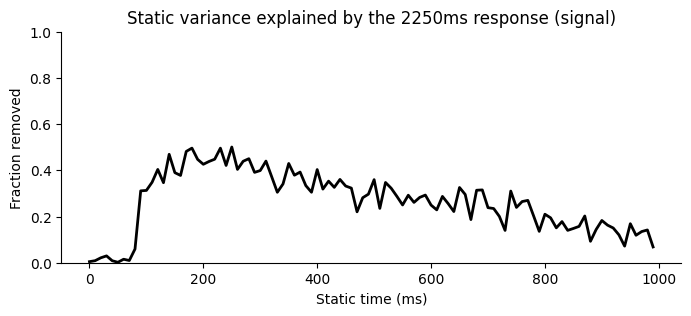

In [26]:
data_dir = Path(paths["data_path"]) / "data"
static_path = data_dir / f"{cfg.static_exp_name}_natraster_img.mat"
dynamic_path = data_dir / f"{cfg.dynamic_exp_name}_natraster_vid.mat"
reliable_channels_config = (
    PROJECT_ROOT / "reliable_channels.yaml" if cfg.use_reliable_channels else None
)

# Apply the identical physical-channel selection to both sessions.
loaded_static, static_names, channel_numbers = load_natraster(
    static_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=cfg.reliable_channels_key or cfg.static_exp_name,
    return_channel_numbers=True,
)
loaded_dynamic, dynamic_names = load_natraster(
    dynamic_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=cfg.reliable_channels_key or cfg.static_exp_name,
)
(
    last_frame_rasters, dynamic_rasters,
    image_2000ms_rasters, image_2250ms_rasters,
    shared_stimuli, _,
) = match_timed_static_movie_rasters(
    loaded_static, static_names, loaded_dynamic, dynamic_names,
)
previous_rasters = {
    "2000ms": image_2000ms_rasters, "2250ms": image_2250ms_rasters, None: None,
}[cfg.previous_static_response]


def resample_rasters(rasters, crop_ms=None):
    if crop_ms is not None:
        rasters = rasters[:, :int(round(crop_ms * cfg.source_fs / 1000)), :]
    # end if crop_ms
    rasters_ts = TimeSeries(rasters, fs=cfg.source_fs)
    rasters_ts.resample(cfg.new_fs)
    return rasters_ts.get_array()
# EOF


static_resampled = resample_rasters(last_frame_rasters, cfg.static_crop_ms)
dynamic_rdms = compute_rdm_timeseries(resample_rasters(dynamic_rasters), cfg.rdm_metric)
static_rdms = {"raw": compute_rdm_timeseries(static_resampled, cfg.rdm_metric)}
variance_removed = None
if previous_rasters is not None:
    previous_resampled = resample_rasters(previous_rasters, cfg.static_crop_ms)
    condition_name = f"{cfg.previous_static_response} regressed"
    if cfg.previous_regression == "signal":
        # Per channel and static bin: OLS across stimuli, keep the residual response.
        residual_rasters, _, _, _ = channelwise_regress_out(
            previous_resampled, static_resampled,
        )
        static_rdms[condition_name] = compute_rdm_timeseries(residual_rasters, cfg.rdm_metric)
        # Fraction of across-stimulus response variance removed, pooled over channels.
        variance_removed = 1 - (
            residual_rasters.var(axis=2).sum(axis=0)
            / static_resampled.var(axis=2).sum(axis=0)
        )
    else:
        static_rdms[condition_name], variance_removed = regress_out_rdm_timeseries(
            static_rdms["raw"],
            compute_rdm_timeseries(previous_resampled, cfg.rdm_metric),
        )
    # end if cfg.previous_regression
# end if previous_rasters is not None
static_times_ms = np.arange(static_resampled.shape[1]) * 1000 / cfg.new_fs
dynamic_times_ms = np.arange(dynamic_rdms.shape[0]) * 1000 / cfg.new_fs
print(
    f"{len(channel_numbers)} channels, {len(shared_stimuli)} stimuli, "
    f"static RDMs {static_rdms['raw'].shape}, dynamic RDMs {dynamic_rdms.shape}"
)
if variance_removed is not None:
    figure, axis = plt.subplots(figsize=(8, 3))
    axis.plot(static_times_ms, variance_removed, color="black", linewidth=2)
    axis.set(
        xlabel="Static time (ms)", ylabel="Fraction removed", ylim=(0, 1),
        title=f"Static variance explained by the {cfg.previous_static_response} response ({cfg.previous_regression})",
    )
    axis.spines[["top", "right"]].set_visible(False)
    plt.show()
# end if variance_removed is not None

## Permutations and significance

In [27]:
results = {}
for condition_name, condition_rdms in static_rdms.items():
    start_time = time.perf_counter()
    observed, null = permuted_cross_temporal_similarity(
        dynamic_rdms, condition_rdms,
        n_permutations=cfg.n_permutations,
        metric=cfg.rsa_metric,
        random_seed=cfg.random_seed,
        n_jobs=cfg.n_jobs,
    )
    p_values = permutation_p_values(observed, null)
    clusters = cluster_permutation_test(observed, null, cluster_alpha=cfg.cluster_alpha)
    # The full null is dropped; it is re-drawn in seconds from the seed.
    del null
    significant_clusters = np.flatnonzero(clusters["p_values"] < cfg.alpha) + 1
    results[condition_name] = {
        "observed": observed,
        "p_values": p_values,
        "clusters": clusters,
        "masks": {
            "pointwise (uncorrected)": p_values["pointwise"] < cfg.alpha,
            "max-statistic (FWE)": p_values["max_statistic"] < cfg.alpha,
            "cluster-mass": np.isin(clusters["labels"], significant_clusters),
        },
    }

    print(f"=== {condition_name}: {time.perf_counter() - start_time:.1f} s, peak {np.nanmax(observed):.3f}")
    for mask_name, mask in results[condition_name]["masks"].items():
        print(f"  {mask_name:24s}: {mask.sum():6d} / {mask.size} cells ({100 * mask.mean():.1f}%)")
    # end for mask_name
    for cluster_id in np.argsort(clusters["p_values"])[:3]:
        print(
            f"  cluster {cluster_id + 1}: {(clusters['labels'] == cluster_id + 1).sum()} cells, "
            f"mass {clusters['masses'][cluster_id]:.1f}, p = {clusters['p_values'][cluster_id]:.4f}"
        )
    # end for cluster_id
# end for condition_name

=== raw: 3.1 s, peak 0.563
  pointwise (uncorrected) :  17636 / 35000 cells (50.4%)
  max-statistic (FWE)     :  10791 / 35000 cells (30.8%)
  cluster-mass            :  15432 / 35000 cells (44.1%)
  cluster 530: 15432 cells, mass 3868.0, p = 0.0010
  cluster 193: 497 cells, mass 20.6, p = 0.1838
  cluster 162: 140 cells, mass 5.9, p = 0.4176
=== 2250ms regressed: 3.1 s, peak 0.452
  pointwise (uncorrected) :  15379 / 35000 cells (43.9%)
  max-statistic (FWE)     :   5723 / 35000 cells (16.4%)
  cluster-mass            :  13599 / 35000 cells (38.9%)
  cluster 621: 13599 cells, mass 2011.4, p = 0.0010
  cluster 232: 54 cells, mass 2.2, p = 0.5085
  cluster 706: 29 cells, mass 1.5, p = 0.6404


## Observed dRSA and its significant parts

One row per static condition. The first column is the full matrix; the others keep only the cells declared significant by each test (grey = not significant). One diverging colour scale, centred on zero, is shared by every panel so the two conditions are directly comparable.

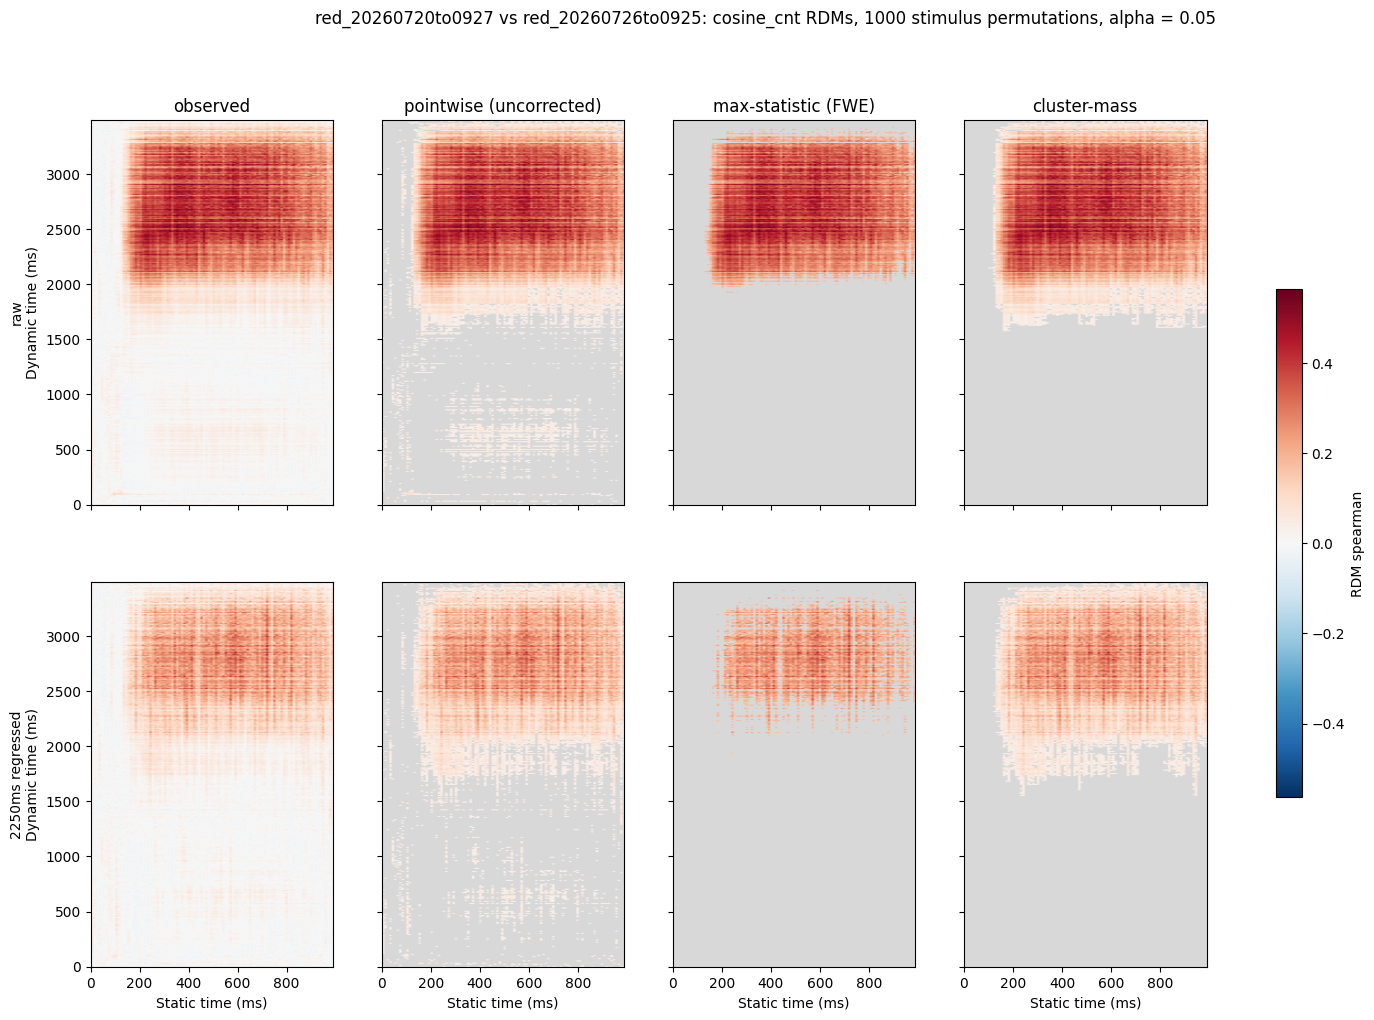

In [28]:
extent = (static_times_ms[0], static_times_ms[-1], dynamic_times_ms[0], dynamic_times_ms[-1])
color_limit = max(np.nanmax(np.abs(result["observed"])) for result in results.values())
colormap = plt.get_cmap("RdBu_r").copy()
colormap.set_bad("0.85")

figure, axes = plt.subplots(
    len(results), 4, figsize=(18, 5.5 * len(results)),
    sharex=True, sharey=True, squeeze=False,
)
for row_axes, (condition_name, result) in zip(axes, results.items()):
    panels = {"observed": np.ones_like(result["observed"], dtype=bool), **result["masks"]}
    for axis, (panel_name, mask) in zip(row_axes, panels.items()):
        image = axis.imshow(
            np.ma.masked_where(~mask, result["observed"]),
            origin="lower", aspect="auto", extent=extent,
            cmap=colormap, vmin=-color_limit, vmax=color_limit,
        )
    # end for axis
    row_axes[0].set_ylabel(f"{condition_name}\nDynamic time (ms)")
# end for row_axes
for axis, panel_name in zip(axes[0], ("observed", *result["masks"])):
    axis.set_title(panel_name)
# end for axis
for axis in axes[-1]:
    axis.set_xlabel("Static time (ms)")
# end for axis
figure.colorbar(image, ax=axes, label=f"RDM {cfg.rsa_metric}", shrink=0.6)
figure.suptitle(
    f"{cfg.dynamic_exp_name} vs {cfg.static_exp_name}: {cfg.rdm_metric} RDMs, "
    f"{cfg.n_permutations} stimulus permutations, alpha = {cfg.alpha}"
)
plt.show()

## Where along the movie does the static geometry come back?

For every dynamic timepoint, the best static match (maximum over static time) of each condition, with its own family-wise threshold (95th percentile of that condition's null matrix maxima, dashed). The lower panel gives the static latency of the best match, only where it is significant.

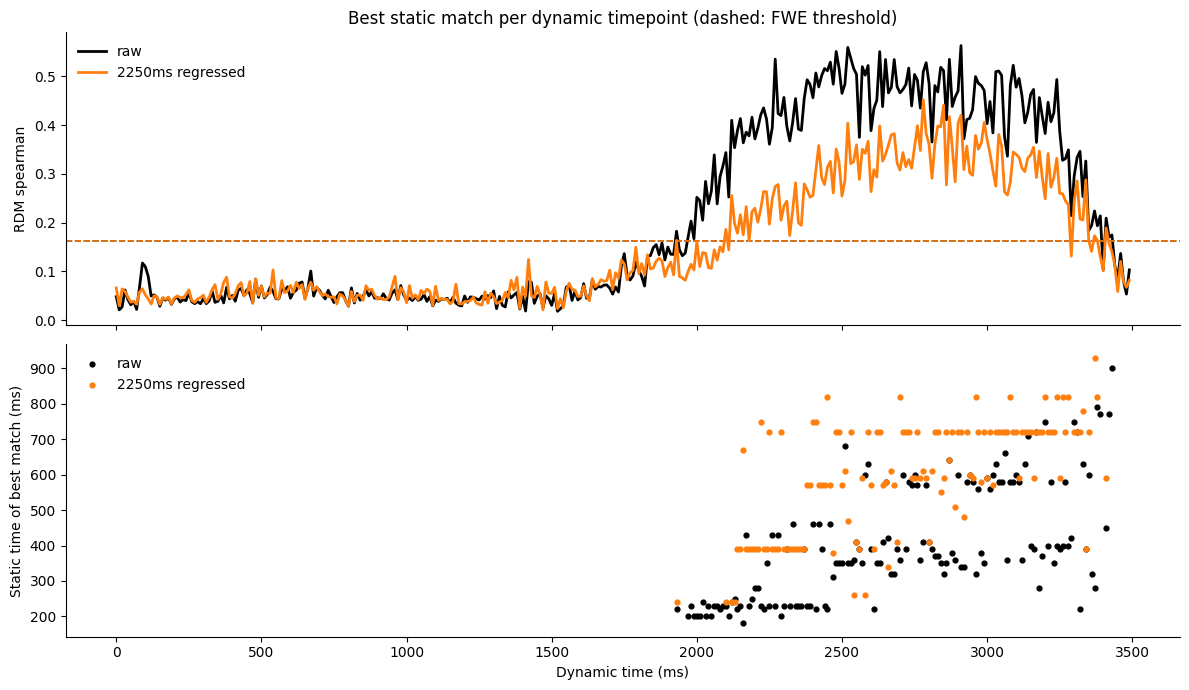

In [29]:
condition_colors = dict(zip(results, ("black", "tab:orange")))
figure, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
for condition_name, result in results.items():
    color = condition_colors[condition_name]
    fwe_threshold = np.nanpercentile(result["p_values"]["null_max"], 100 * (1 - cfg.alpha))
    best_static_similarity = np.nanmax(result["observed"], axis=1)
    best_static_time_ms = static_times_ms[np.nanargmax(result["observed"], axis=1)]
    significant_dynamic = best_static_similarity > fwe_threshold
    axes[0].plot(dynamic_times_ms, best_static_similarity, color=color, linewidth=2, label=condition_name)
    axes[0].axhline(fwe_threshold, color=color, linewidth=1.2, linestyle="--")
    axes[1].scatter(
        dynamic_times_ms[significant_dynamic], best_static_time_ms[significant_dynamic],
        color=color, s=12, label=condition_name,
    )
# end for condition_name
axes[0].set(ylabel=f"RDM {cfg.rsa_metric}", title="Best static match per dynamic timepoint (dashed: FWE threshold)")
axes[1].set(xlabel="Dynamic time (ms)", ylabel="Static time of best match (ms)")
for axis in axes:
    axis.legend(frameon=False)
    axis.spines[["top", "right"]].set_visible(False)
# end for axis
figure.tight_layout()
plt.show()

## Null distributions

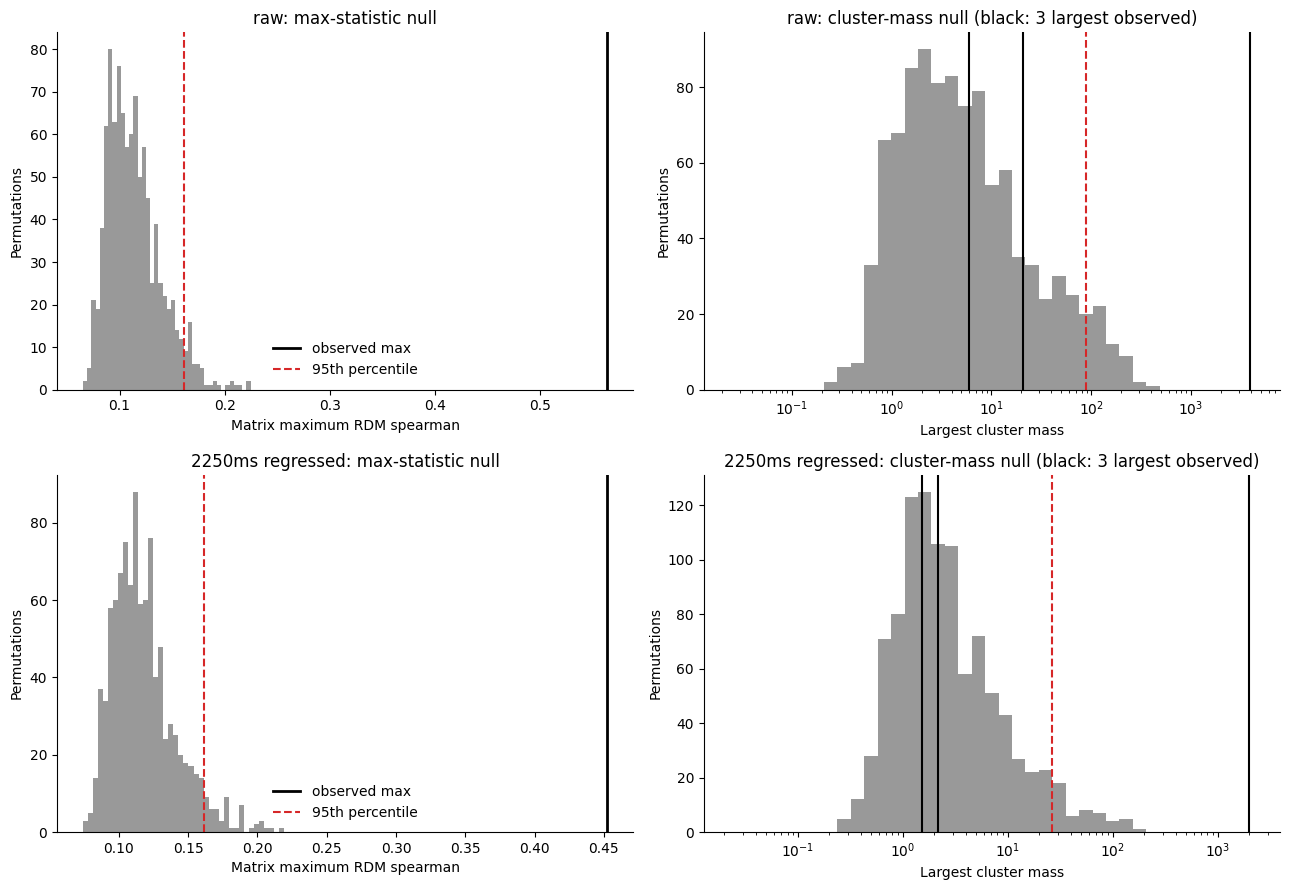

In [30]:
figure, axes = plt.subplots(len(results), 2, figsize=(13, 4.5 * len(results)), squeeze=False)
for row_axes, (condition_name, result) in zip(axes, results.items()):
    null_max = result["p_values"]["null_max"]
    clusters = result["clusters"]
    row_axes[0].hist(null_max, bins=40, color="0.6")
    row_axes[0].axvline(np.nanmax(result["observed"]), color="black", linewidth=2, label="observed max")
    row_axes[0].axvline(np.nanpercentile(null_max, 100 * (1 - cfg.alpha)), color="tab:red", linestyle="--", label="95th percentile")
    row_axes[0].set(xlabel=f"Matrix maximum RDM {cfg.rsa_metric}", ylabel="Permutations", title=f"{condition_name}: max-statistic null")
    row_axes[0].legend(frameon=False)

    # Cluster masses span orders of magnitude: log-spaced bins on a log axis.
    positive_masses = np.concatenate([clusters["null_max_mass"], clusters["masses"]])
    positive_masses = positive_masses[positive_masses > 0]
    mass_bins = np.logspace(np.log10(positive_masses.min()), np.log10(positive_masses.max() * 1.1), 40)
    row_axes[1].hist(clusters["null_max_mass"], bins=mass_bins, color="0.6")
    for cluster_id in np.argsort(clusters["p_values"])[:3]:
        row_axes[1].axvline(clusters["masses"][cluster_id], color="black", linewidth=1.5)
    # end for cluster_id
    row_axes[1].axvline(np.nanpercentile(clusters["null_max_mass"], 100 * (1 - cfg.alpha)), color="tab:red", linestyle="--")
    row_axes[1].set(
        xlabel="Largest cluster mass", ylabel="Permutations", xscale="log",
        title=f"{condition_name}: cluster-mass null (black: 3 largest observed)",
    )
    for axis in row_axes:
        axis.spines[["top", "right"]].set_visible(False)
    # end for axis
# end for row_axes
figure.tight_layout()
plt.show()

## Save

In [22]:
if cfg.save_results:
    output_dir = (
        PROJECT_ROOT / "results" / "static_dynamic_drsa_permutation"
        / f"{cfg.dynamic_exp_name}_vs_{cfg.static_exp_name}"
    )
    output_dir.mkdir(parents=True, exist_ok=True)
    for condition_name, result in results.items():
        condition_suffix = (
            "raw" if condition_name == "raw"
            else f"{cfg.previous_static_response}-{cfg.previous_regression}-regressed"
        )
        output_path = output_dir / (
            f"{cfg.rdm_metric}_{cfg.rsa_metric}_{condition_suffix}_"
            f"{cfg.n_permutations}perm_seed{cfg.random_seed}.npz"
        )
        np.savez_compressed(
            output_path,
            observed=result["observed"],
            pointwise_p=result["p_values"]["pointwise"],
            max_statistic_p=result["p_values"]["max_statistic"],
            null_max=result["p_values"]["null_max"],
            cluster_labels=result["clusters"]["labels"],
            cluster_masses=result["clusters"]["masses"],
            cluster_p=result["clusters"]["p_values"],
            null_max_cluster_mass=result["clusters"]["null_max_mass"],
            static_times_ms=static_times_ms,
            dynamic_times_ms=dynamic_times_ms,
            shared_stimuli=np.asarray(shared_stimuli),
            channel_numbers=channel_numbers,
            config=np.asarray(str(asdict(cfg))),
        )
        print(f"Saved {output_path}")
    # end for condition_name
# end if cfg.save_results

Saved /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_drsa_permutation/baby1_260716to24_vs_baby1_260718to27/cosine_cnt_spearman_raw_1000perm_seed0.npz
Saved /Users/tizianocausin/Desktop/static_dynamic/results/static_dynamic_drsa_permutation/baby1_260716to24_vs_baby1_260718to27/cosine_cnt_spearman_2250ms-signal-regressed_1000perm_seed0.npz
